# 03 · Entrenamiento **Vía B** — ventana cruda + Conv1D

**Miniproyecto 1 TinyML (UAO 2026-2) — proyecto Bartender.**

Esta es la vía que el profesor usó **en vivo en la clase del 15-sep**: la
ventana normalizada entra tal cual a una red convolucional, sin ingeniería de
características.

> Vía B · *Datos crudos + aprendizaje profundo.* La ventana entra tal cual
> (W × ejes) a una **Conv1D**. Más cómputo y más datos, pero sin ingeniería
> manual.

La Vía A (39 características + densa 20/10) está en
[`02_entrenamiento_A_caracteristicas.ipynb`](02_entrenamiento_A_caracteristicas.ipynb).
Al final de este notebook se comparan las dos.

## Qué hay que subir a Colab

La carpeta `edge-impulse/dataset/` del repo (o un `.zip` de ella):

```
dataset/
  info-6clases.labels          <- etiquetas buenas: 6 clases × 10 tomas
  training/*.cbor              <- 60 tomas
```

> ⚠️ **No `info.labels`**: trae 60 etiquetas, una por toma (issue #1).

## Qué se cambia respecto al código de clase, y por qué

| En clase | Aquí | Motivo |
|---|---|---|
| `pd.read_json`, `Valores[7,2]` | `cbor2.load`, `payload.values` | nuestro export es **CBOR**, no JSON |
| 100 Hz | **62,5 Hz** | `interval_ms = 16,0` |
| `ventana = 100` (= 1,0 s allí) | **`W = 125`** (= 2,00 s aquí) | copiar el 100 daría 1,6 s. 2 s a 62,5 Hz **son 125 muestras** |
| `paso = 50` (50 % solape) | **`S = 25`** (80 % solape) | sube de 444 a 1020 ventanas; no infla la métrica porque el split es por toma |
| Índices fijos `c*6000 : c*6000+6000` | ventaneo por toma | nuestras tomas no duran todas lo mismo (4 s y 10 s) |
| `StandardScaler` sobre **todo** | ajustado **solo en train** | ajustar en todo filtra estadísticos del test |
| Sin partición de test | **`GroupShuffleSplit` por toma** | issue #3: ventanas solapadas a los dos lados inflan la exactitud |
| 3 ejes (solo tenía 3) | **3 ejes**, elegidos midiendo | `mag` fuera por sesgo de sitio (issue #5); `gyr` fuera porque **empeora**, se mide abajo |


## 1 · Instalación

In [1]:
# --- Celda de instalacion: ejecutar primero en Colab ---
# Colab ya trae numpy, scipy, scikit-learn, matplotlib, pandas y tensorflow.
# Lo unico que falta es cbor2, porque el export de Edge Impulse es .cbor (NO .json).
%pip install -q cbor2

import importlib
for m in ['cbor2', 'numpy', 'scipy', 'sklearn', 'matplotlib', 'pandas']:
    mod = importlib.import_module(m)
    print(f'{m:12s}', getattr(mod, '__version__', 'ok'))
try:
    import tensorflow as tf
    print(f'{"tensorflow":12s}', tf.__version__)
except Exception as e:
    print('tensorflow no disponible:', e)


Note: you may need to restart the kernel to use updated packages.
cbor2        ok


numpy        2.5.2
scipy        1.18.1


sklearn      1.9.1
matplotlib   3.11.1
pandas       3.0.6


I0000 00:00:1790037061.421704  955718 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow   2.21.0


## 2 · Cargar el dataset

In [2]:
# --- Celda de datos: localizar o subir el dataset ---
# QUE HAY QUE SUBIR
#   Una carpeta (o un .zip de ella) con esta estructura exacta:
#
#     dataset/
#       info-6clases.labels        <- etiquetas BUENAS (6 clases x 10 tomas)
#       training/
#         Agitar 01.*.cbor ... servir 10.*.cbor   (60 archivos)
#
#   En el repo esta en  edge-impulse/dataset/.
#   NO subas info.labels: trae 60 etiquetas distintas, una por toma (issue #1).
#
# Tres formas de darle los datos al notebook, en orden de preferencia:
#   1. Variable de entorno MP1_DATASET con la ruta (ejecucion local).
#   2. Montar Google Drive y dejar la carpeta en MyDrive/tinyml/dataset.
#   3. Subir un zip con files.upload() (se descomprime aqui mismo).

import os, glob, zipfile

CANDIDATOS = [
    os.environ.get('MP1_DATASET', ''),
    'dataset', 'edge-impulse/dataset', '../edge-impulse/dataset',
    '/content/dataset', '/content/edge-impulse/dataset',
    '/content/drive/MyDrive/tinyml/dataset',
]

def _es_dataset(p):
    return bool(p) and os.path.isfile(os.path.join(p, 'info-6clases.labels')) \
                   and os.path.isdir(os.path.join(p, 'training'))

def localiza_dataset():
    for p in CANDIDATOS:
        if _es_dataset(p):
            return os.path.abspath(p)
    # Nada encontrado: pedir el zip (solo funciona dentro de Colab)
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(
            'No encuentro el dataset. Define MP1_DATASET=/ruta/a/edge-impulse/dataset '
            'o copia la carpeta junto al notebook.')
    print('Sube un .zip que contenga info-6clases.labels y training/*.cbor')
    subidos = files.upload()
    for nombre in subidos:
        if nombre.endswith('.zip'):
            with zipfile.ZipFile(nombre) as z:
                z.extractall('/content/subido')
    # el zip puede traer la carpeta anidada a cualquier profundidad
    for ruta in glob.glob('/content/subido/**/info-6clases.labels', recursive=True):
        return os.path.dirname(ruta)
    raise FileNotFoundError('El zip no contiene info-6clases.labels')

RAIZ = localiza_dataset()
print('dataset en:', RAIZ)
print('tomas .cbor:', len(glob.glob(os.path.join(RAIZ, 'training', '*.cbor'))))


dataset en: /home/caesar/Projects/miniproyecto1-tinyml/edge-impulse/dataset
tomas .cbor: 60


## 3 · Decodificar y ventanear

In [3]:
# --- Decodificacion CBOR ---
import json, numpy as np

FS_ESPERADA = 62.5   # Hz. interval_ms = 16.0  ->  1000/16 = 62.5
SENSORES_9  = ['accX','accY','accZ','gyrX','gyrY','gyrZ','magX','magY','magZ']

def cargar_dataset(raiz):
    """Lee info-6clases.labels y decodifica cada .cbor.

    Devuelve una lista de dicts: nombre, archivo (= grupo para el split),
    clase, valores (N x 9 float32), sensores, interval_ms.
    """
    import cbor2
    info = json.load(open(os.path.join(raiz, 'info-6clases.labels')))
    tomas = []
    for e in info['files']:
        ruta = os.path.join(raiz, e['path'])
        with open(ruta, 'rb') as fh:
            d = cbor2.load(fh)
        pl = d['payload']
        tomas.append(dict(
            nombre      = e['name'],
            archivo     = os.path.basename(ruta),     # <- grupo del split por toma
            clase       = e['label']['label'],
            valores     = np.asarray(pl['values'], dtype=np.float32),
            sensores    = [s['name'] for s in pl['sensors']],
            interval_ms = float(pl['interval_ms']),
        ))
    return tomas

tomas  = cargar_dataset(RAIZ)
CLASES = sorted({t['clase'] for t in tomas})
print(f'{len(tomas)} tomas, {len(CLASES)} clases: {CLASES}')

# Verificacion dura: la frecuencia de muestreo es la que creemos
intervalos = {t['interval_ms'] for t in tomas}
assert intervalos == {16.0}, f'interval_ms inesperado: {intervalos}'
FS = 1000.0 / 16.0
assert abs(FS - FS_ESPERADA) < 1e-9
print(f'interval_ms = 16.0  ->  fs = {FS} Hz   (NO 100 Hz)')


60 tomas, 6 clases: ['agitar', 'macerar', 'remover', 'reposo', 'reposo_mano', 'servir']
interval_ms = 16.0  ->  fs = 62.5 Hz   (NO 100 Hz)


In [4]:
# --- Seleccion de ejes y ventaneo ---
EJES_ACC  = ['accX','accY','accZ']
EJES_GIR  = ['gyrX','gyrY','gyrZ']
EJES_MAG  = ['magX','magY','magZ']
# EJES QUE ENTRAN AL MODELO: solo acelerometro.
#   - mag* fuera por diseno: codifican orientacion y sitio de captura, no gesto
#     (issue #5). Meterlos SUBE la exactitud, y esa subida es la fuga.
#   - gyr* fuera POR MEDICION: se probo anadirlos y empeoran las dos vias en
#     validacion cruzada agrupada (notebooks 02 y 03, seccion de ablacion).
# Con 3 ejes la Via A da exactamente las 39 caracteristicas del PDF.
EJES_USADOS = EJES_ACC

def selecciona_ejes(toma, ejes):
    idx = [toma['sensores'].index(a) for a in ejes]
    return toma['valores'][:, idx]

def ventanear(tomas, ejes, W, S):
    """Ventanas deslizantes. Devuelve X (n,W,C), y (clase) y g (archivo origen).

    `g` es lo que despues agrupa el split: TODAS las ventanas de una toma caen
    del mismo lado de la particion. Sin esto, ventanas solapadas de la misma
    toma acaban en train y en test y la exactitud sale inflada (issue #3).
    """
    X, y, g = [], [], []
    for t in tomas:
        m = selecciona_ejes(t, ejes)
        for i in range(0, len(m) - W + 1, S):
            X.append(m[i:i+W]); y.append(t['clase']); g.append(t['archivo'])
    return np.asarray(X, np.float32), np.asarray(y), np.asarray(g)


In [5]:
import pandas as pd

W, S = 125, 25        # 2,00 s de ventana, 0,4 s de paso
assert abs(W/FS - 2.0) < 1e-9, 'W debe ser 2 s a 62,5 Hz'

X, y, g = ventanear(tomas, EJES_USADOS, W, S)
print(f'X {X.shape}  ({X.shape[0]} ventanas × {W} muestras × {X.shape[2]} ejes)')
print(f'ejes usados: {EJES_USADOS}')
print(f'grupos (tomas) distintos: {len(set(g))}\n')
print(pd.Series(y).value_counts().reindex(CLASES).to_string())


X (1020, 125, 3)  (1020 ventanas × 125 muestras × 3 ejes)
ejes usados: ['accX', 'accY', 'accZ']
grupos (tomas) distintos: 60

agitar         120
macerar        210
remover         60
reposo         210
reposo_mano    210
servir         210


## 4 · Split **por toma**, nunca por ventana

In [6]:
# --- Split POR TOMA (nunca por ventana) ---
from sklearn.model_selection import GroupShuffleSplit

def split_por_toma(y, g, test_size=0.25, seed=42, n_try=50):
    """GroupShuffleSplit agrupando por archivo de origen.

    GroupShuffleSplit no estratifica: con 60 grupos y 6 clases una particion
    puede dejar una clase entera fuera del test. Por eso se recorren varias
    particiones del mismo generador y se devuelve la primera en la que las 6
    clases aparecen a ambos lados. Sigue siendo un split por toma puro.
    """
    clases = set(y)
    gss = GroupShuffleSplit(n_splits=n_try, test_size=test_size, random_state=seed)
    for k, (tr, te) in enumerate(gss.split(np.zeros(len(y)), y, groups=g)):
        if set(y[tr]) == clases and set(y[te]) == clases:
            return tr, te, k
    raise RuntimeError('ninguna de las %d particiones cubre las 6 clases' % n_try)

def verifica_sin_fuga(g, idx_a, idx_b, nombre_a='train', nombre_b='test'):
    """Comprueba que ninguna toma aparece en las dos particiones."""
    ta, tb = set(g[idx_a]), set(g[idx_b])
    comunes = ta & tb
    assert not comunes, f'FUGA: {len(comunes)} tomas en {nombre_a} y {nombre_b}'
    print(f'sin fuga: {len(ta)} tomas en {nombre_a}, {len(tb)} en {nombre_b}, 0 compartidas')


In [7]:
import numpy as np

tr_val, i_test, k = split_por_toma(y, g, test_size=0.25, seed=42)
sub_tr, sub_val, _ = split_por_toma(y[tr_val], g[tr_val], test_size=0.20, seed=43)
i_train, i_val = tr_val[sub_tr], tr_val[sub_val]

print(f'partición GroupShuffleSplit #{k}\n')
verifica_sin_fuga(g, i_train, i_test, 'train', 'test')
verifica_sin_fuga(g, i_val,   i_test, 'val',   'test')
verifica_sin_fuga(g, i_train, i_val,  'train', 'val')

rep = pd.DataFrame({
    'train': pd.Series(y[i_train]).value_counts(),
    'val':   pd.Series(y[i_val]).value_counts(),
    'test':  pd.Series(y[i_test]).value_counts()}).reindex(CLASES).fillna(0).astype(int)
rep.loc['TOTAL ventanas'] = rep.sum()
rep.loc['TOTAL tomas'] = [len(set(g[i])) for i in (i_train, i_val, i_test)]
print('\n', rep.to_string())


partición GroupShuffleSplit #1

sin fuga: 36 tomas en train, 15 en test, 0 compartidas
sin fuga: 9 tomas en val, 15 en test, 0 compartidas
sin fuga: 36 tomas en train, 9 en val, 0 compartidas

                 train  val  test
agitar             81   12    27
macerar           147   21    42
remover            24   18    18
reposo            168   21    21
reposo_mano       105   21    84
servir            126   21    63
TOTAL ventanas    651  114   255
TOTAL tomas        36    9    15


## 5 · Normalización

Igual que en clase se usa estandarización por eje, con una diferencia: la media
y la desviación se calculan **solo con las ventanas de entrenamiento**. Esas 6
constantes (3 medias + 3 desviaciones) hay que copiarlas al sketch del Arduino;
si el MCU normaliza con otros números, el modelo ve una distribución que no
conoce.

In [8]:
# --- Metricas: matriz de confusion y desglose por clase ---
def matriz_confusion(y_true, y_pred, clases):
    ix = {c: i for i, c in enumerate(clases)}
    M = np.zeros((len(clases), len(clases)), int)
    for a, b in zip(y_true, y_pred):
        M[ix[a], ix[b]] += 1
    return M

def reporte_por_clase(M, clases):
    filas = []
    for i, c in enumerate(clases):
        sop  = M[i].sum(); tp = M[i, i]; pred = M[:, i].sum()
        rec  = tp/sop  if sop  else 0.0
        prec = tp/pred if pred else 0.0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
        filas.append(dict(clase=c, soporte=int(sop), recall=rec, precision=prec, f1=f1))
    return pd.DataFrame(filas)

def pinta_confusion(M, clases, titulo, normaliza=True):
    D = M.astype(float)
    if normaliza:
        D = D / np.maximum(D.sum(1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    im = ax.imshow(D, cmap='Blues', vmin=0, vmax=1 if normaliza else D.max())
    ax.set_xticks(range(len(clases)), clases, rotation=45, ha='right')
    ax.set_yticks(range(len(clases)), clases)
    ax.set_xlabel('prediccion'); ax.set_ylabel('real'); ax.set_title(titulo)
    for i in range(len(clases)):
        for j in range(len(clases)):
            txt = f'{D[i,j]:.2f}' if normaliza else f'{M[i,j]}'
            ax.text(j, i, txt, ha='center', va='center',
                    color='white' if D[i, j] > 0.55*D.max() else '#222', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8); fig.tight_layout(); plt.show()


In [9]:
# --- Conv1D sobre la ventana cruda normalizada ---
import warnings, logging
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel(logging.ERROR)

def construye_modelo_b(W, n_ejes, n_clases, semilla=42):
    """Red convolucional 1D pequeña, pensada para caber en un nRF52840.

    Conv1D(16,5) -> MaxPool(3) -> Conv1D(32,5) -> MaxPool(3) -> Conv1D(32,3)
                 -> GlobalAveragePooling1D -> Dropout -> softmax

    Por qué así:
      - Kernel 5 a 62,5 Hz cubre 80 ms: la escala de un golpe de hielo.
      - Dos MaxPool de 3 reducen 125 -> 41 -> 13 pasos; la tercera conv ve
        entonces un campo receptivo de ~1 s, la escala del gesto completo.
      - GlobalAveragePooling en vez de Flatten+Dense: quita de golpe la mayor
        parte de los pesos (un Flatten daría 13*32=416 entradas a la densa) y
        hace el modelo invariante a DONDE dentro de la ventana ocurre el gesto.
      - Sin capa densa intermedia: con ~1000 ventanas de entrenamiento, cada
        parámetro de más es sobreajuste.
    """
    keras.utils.set_random_seed(semilla)
    m = keras.Sequential([
        keras.layers.Input((W, n_ejes), name='ventana'),
        keras.layers.Conv1D(16, 5, activation='relu', padding='same', name='conv_16'),
        keras.layers.MaxPooling1D(3, name='pool_1'),
        keras.layers.Conv1D(32, 5, activation='relu', padding='same', name='conv_32a'),
        keras.layers.MaxPooling1D(3, name='pool_2'),
        keras.layers.Conv1D(32, 3, activation='relu', padding='same', name='conv_32b'),
        keras.layers.GlobalAveragePooling1D(name='gap'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(n_clases, activation='softmax', name='salida'),
    ], name='via_b')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

def pesos_de_clase(y_idx, n_clases):
    """class_weight inverso a la frecuencia: corrige el desbalance de `remover`
    (5,9 % de las ventanas, issue #4)."""
    return {i: len(y_idx)/(n_clases*max(1, int((y_idx == i).sum())))
            for i in range(n_clases)}

def normalizador(X_train):
    """Media y desviación POR EJE, calculadas SOLO con las ventanas de train.

    El profesor aplicaba StandardScaler sobre todos los datos antes de partir;
    eso filtra estadísticos del test al entrenamiento. Aquí se ajusta en train
    y se aplica tal cual a val y test. Además, estas dos constantes (3 medias y
    3 desviaciones) son las que hay que copiar al sketch del Arduino para
    normalizar en el MCU exactamente igual que en el entrenamiento.
    """
    plano = X_train.reshape(-1, X_train.shape[2])
    mu, sd = plano.mean(0), plano.std(0) + 1e-8
    return mu.astype('f4'), sd.astype('f4')


In [10]:
IX = {c: i for i, c in enumerate(CLASES)}
a_idx = lambda v: np.array([IX[c] for c in v])

mu, sd = normalizador(X[i_train])
norm = lambda A: ((A - mu)/sd).astype('f4')
Xtr, Xva, Xte = norm(X[i_train]), norm(X[i_val]), norm(X[i_test])
y_train, y_val, y_test = a_idx(y[i_train]), a_idx(y[i_val]), a_idx(y[i_test])

print('constantes de normalización — COPIAR AL SKETCH DEL ARDUINO')
for e, m_, s_ in zip(EJES_USADOS, mu, sd):
    print(f'  {e}: media = {m_:+.6f}   desv = {s_:.6f}')
print(f'\nXtr {Xtr.shape}  media {Xtr.mean():+.4f}  desv {Xtr.std():.4f}')
print(f'Xte {Xte.shape}  media {Xte.mean():+.4f}  desv {Xte.std():.4f}   '
      '<- no tiene por qué dar 0/1: se normaliza con las constantes de train')


constantes de normalización — COPIAR AL SKETCH DEL ARDUINO
  accX: media = +0.301136   desv = 4.454137
  accY: media = -6.670692   desv = 7.257038
  accZ: media = +1.472643   desv = 3.156127

Xtr (651, 125, 3)  media +0.0000  desv 1.0000
Xte (255, 125, 3)  media +0.0591  desv 0.8907   <- no tiene por qué dar 0/1: se normaliza con las constantes de train


## 6 · El modelo

In [11]:
modelo = construye_modelo_b(W, len(EJES_USADOS), len(CLASES), semilla=42)
modelo.summary()
print('\nclass_weight (corrige el desbalance de remover):')
cw = pesos_de_clase(y_train, len(CLASES))
print({CLASES[i]: round(v, 2) for i, v in cw.items()})


Model: "via_b"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_16 (Conv1D)                │ (None, 125, 16)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling1D)           │ (None, 41, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_32a (Conv1D)               │ (None, 41, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling1D)           │ (None, 13, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_32b (Conv1D)               │ (None, 13, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,150 (24.02 KB)

 Trainable params: 6,150 (24.02 KB)

 Non-trainable params: 0 (0.00 B)


class_weight (corrige el desbalance de remover):
{'agitar': 1.34, 'macerar': 0.74, 'remover': 4.52, 'reposo': 0.65, 'reposo_mano': 1.03, 'servir': 0.86}


## 7 · Entrenamiento

In [12]:
parada = keras.callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                       restore_best_weights=True)
hist = modelo.fit(Xtr, y_train, validation_data=(Xva, y_val),
                  epochs=250, batch_size=32, verbose=0,
                  class_weight=cw, callbacks=[parada])
print(f'entrenadas {len(hist.history["loss"])} épocas '
      f'(early stopping, mejor val_loss restaurado)')


entrenadas 176 épocas (early stopping, mejor val_loss restaurado)


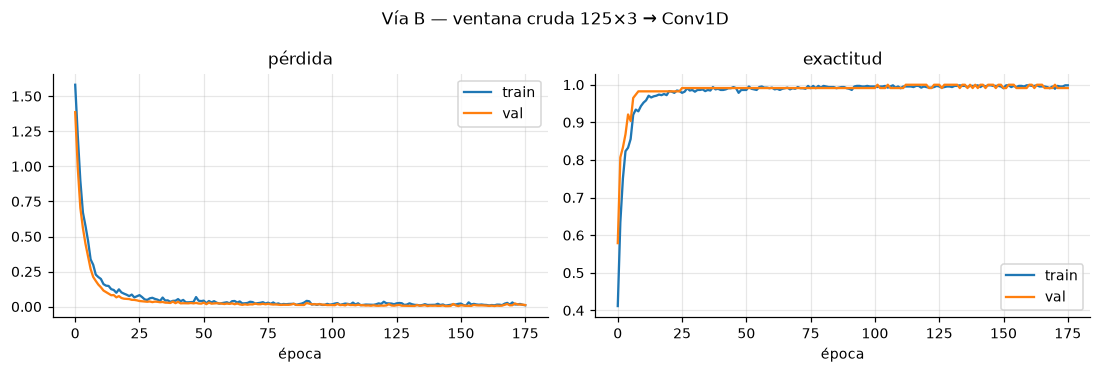

In [13]:
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(hist.history['loss'], label='train'); ax[0].plot(hist.history['val_loss'], label='val')
ax[0].set_title('pérdida'); ax[0].set_xlabel('época'); ax[0].legend()
ax[1].plot(hist.history['accuracy'], label='train'); ax[1].plot(hist.history['val_accuracy'], label='val')
ax[1].set_title('exactitud'); ax[1].set_xlabel('época'); ax[1].legend()
fig.suptitle('Vía B — ventana cruda 125×3 → Conv1D')
fig.tight_layout(); plt.show()


## 8 · Evaluación: matriz de confusión y exactitud **por clase**

In [14]:
p_test = modelo.predict(Xte, verbose=0).argmax(1)
acc_global = float((p_test == y_test).mean())
M = matriz_confusion(y[i_test], np.array(CLASES)[p_test], CLASES)
tabla = reporte_por_clase(M, CLASES)

print(f'exactitud GLOBAL (float32) : {acc_global:.4f}')
print(f'exactitud MEDIA POR CLASE  : {tabla["recall"].mean():.4f}\n')
print(tabla.round(3).to_string(index=False))
print('\nmatriz de confusión (filas = real, columnas = predicho)')
print(pd.DataFrame(M, index=CLASES, columns=CLASES).to_string())


exactitud GLOBAL (float32) : 0.9333
exactitud MEDIA POR CLASE  : 0.9153

      clase  soporte  recall  precision    f1
     agitar       27   1.000      1.000 1.000
    macerar       42   1.000      0.840 0.913
    remover       18   0.667      0.923 0.774
     reposo       21   1.000      0.913 0.955
reposo_mano       84   1.000      1.000 1.000
     servir       63   0.825      0.897 0.860

matriz de confusión (filas = real, columnas = predicho)
             agitar  macerar  remover  reposo  reposo_mano  servir
agitar           27        0        0       0            0       0
macerar           0       42        0       0            0       0
remover           0        0       12       0            0       6
reposo            0        0        0      21            0       0
reposo_mano       0        0        0       0           84       0
servir            0        8        1       2            0      52


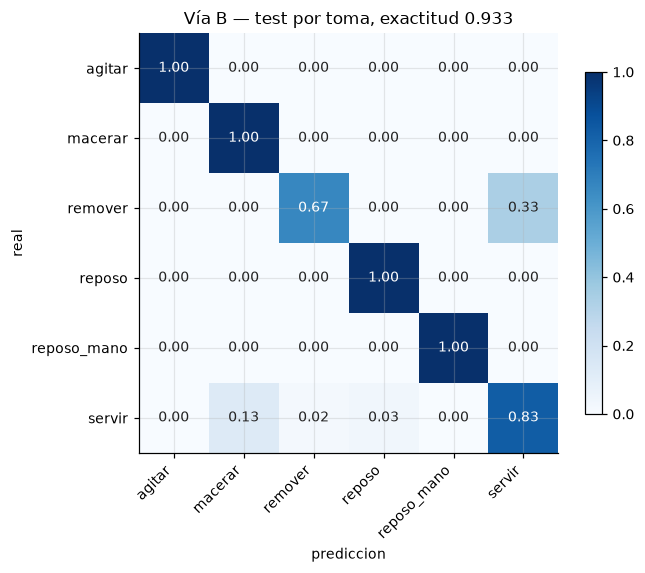

In [15]:
pinta_confusion(M, CLASES, f"Vía B — test por toma, exactitud {acc_global:.3f}")


> Recordatorio del notebook 02: `GroupShuffleSplit` no estratifica, así que
> este test único reparte mal las tomas (4 de `reposo_mano`, 1 de `reposo`).
> El número que hay que citar es el de la **validación cruzada agrupada** de la
> sección 10.

## 9 · Qué mira la red — filtros y activaciones

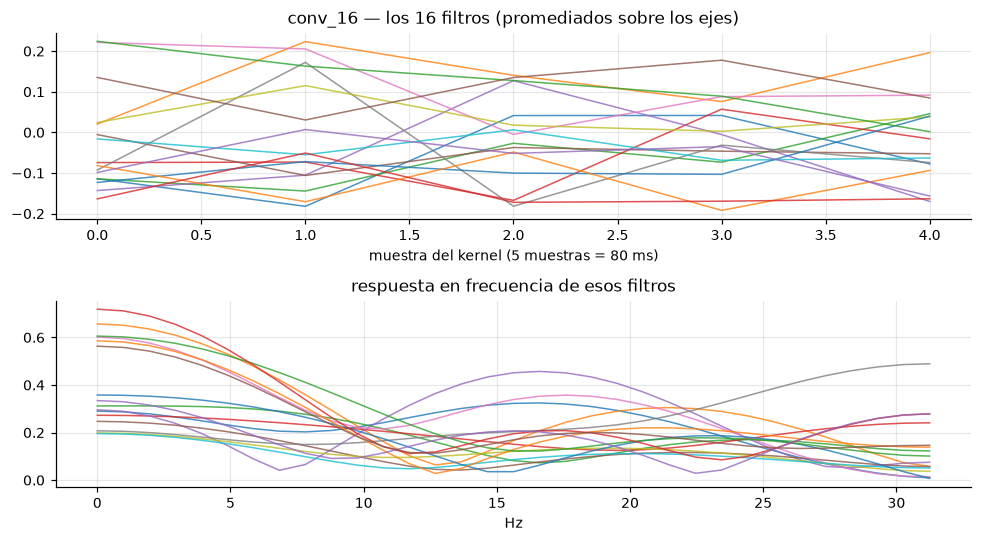

Las f dominantes medidas en el notebook 01 (servir 1,9 Hz · macerar 3,2 Hz ·
agitar 5,8 Hz) caen dentro del rango que cubren estos filtros.


In [16]:
# Los 16 filtros de la primera capa, en el dominio del tiempo y en frecuencia
Wc = modelo.get_layer('conv_16').get_weights()[0]      # (5, n_ejes, 16)
fig, axes = plt.subplots(2, 1, figsize=(9, 5))
for f in range(Wc.shape[2]):
    axes[0].plot(Wc[:, :, f].mean(1), lw=1, alpha=0.8)
axes[0].set_title('conv_16 — los 16 filtros (promediados sobre los ejes)')
axes[0].set_xlabel('muestra del kernel (5 muestras = 80 ms)')

n = 64
for f in range(Wc.shape[2]):
    h = np.abs(np.fft.rfft(Wc[:, :, f].mean(1), n))
    axes[1].plot(np.fft.rfftfreq(n, 1/FS), h, lw=1, alpha=0.8)
axes[1].set_title('respuesta en frecuencia de esos filtros')
axes[1].set_xlabel('Hz')
fig.tight_layout(); plt.show()
print('Las f dominantes medidas en el notebook 01 (servir 1,9 Hz · macerar 3,2 Hz ·')
print('agitar 5,8 Hz) caen dentro del rango que cubren estos filtros.')


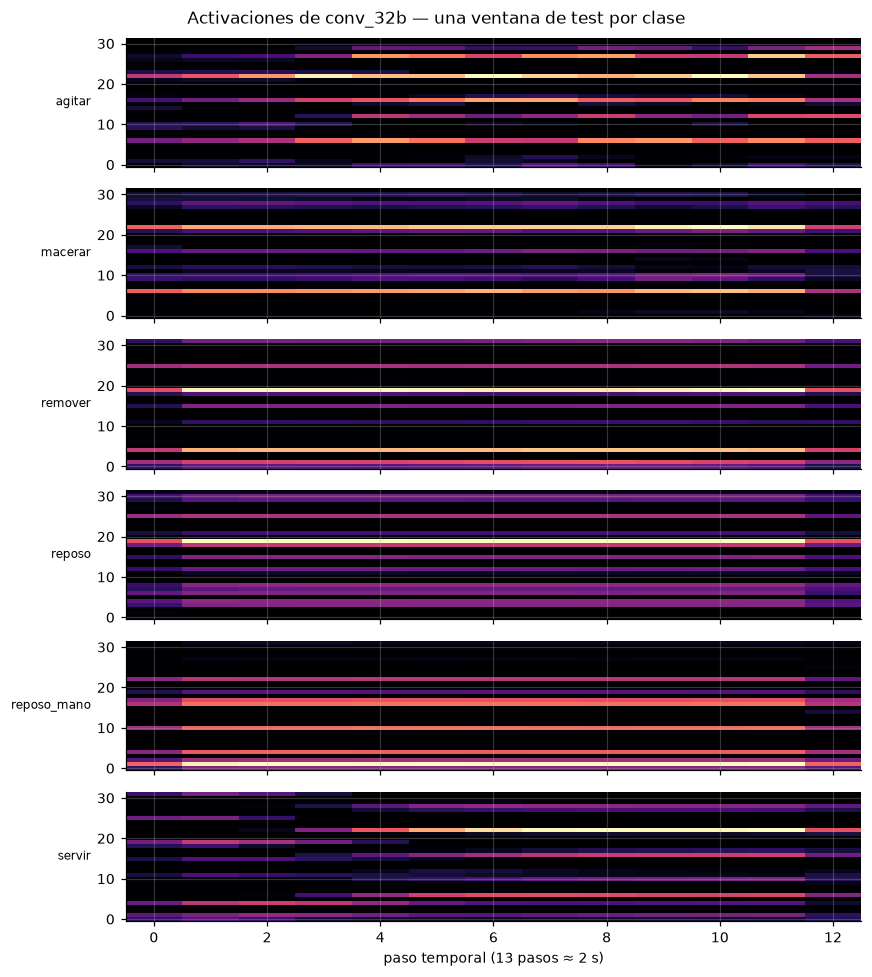

In [17]:
# Mapa de activación de la última conv para una ventana de cada clase
capa = keras.Model(modelo.inputs, modelo.get_layer('conv_32b').output)
fig, axes = plt.subplots(len(CLASES), 1, figsize=(8, 1.5*len(CLASES)), sharex=True)
for ax, c in zip(axes, CLASES):
    idx = np.where(y[i_test] == c)[0]
    if len(idx) == 0:
        ax.set_visible(False); continue
    A = capa.predict(Xte[idx[:1]], verbose=0)[0]       # (13, 32)
    ax.imshow(A.T, aspect='auto', cmap='magma', origin='lower')
    ax.set_ylabel(c, rotation=0, ha='right', va='center', fontsize=8)
axes[-1].set_xlabel('paso temporal (13 pasos ≈ 2 s)')
fig.suptitle('Activaciones de conv_32b — una ventana de test por clase')
fig.tight_layout(); plt.show()


## 10 · Validación cruzada agrupada y ablación de ejes

Vía B con solo acelerómetro (3 ejes) — configuración elegida


  pliegue 0: 0.9952  (12 tomas en test)


  pliegue 1: 0.9710  (12 tomas en test)


  pliegue 2: 0.9900  (11 tomas en test)


  pliegue 3: 0.9751  (11 tomas en test)


  pliegue 4: 1.0000  (14 tomas en test)

exactitud CV agrupada: 0.9863 ± 0.0113
exactitud media por clase: 0.9770

      clase  soporte  recall  precision    f1
     agitar      120   1.000      1.000 1.000
    macerar      210   1.000      0.986 0.993
    remover       60   0.900      0.947 0.923
     reposo      210   1.000      0.991 0.995
reposo_mano      210   1.000      1.000 1.000
     servir      210   0.962      0.971 0.967


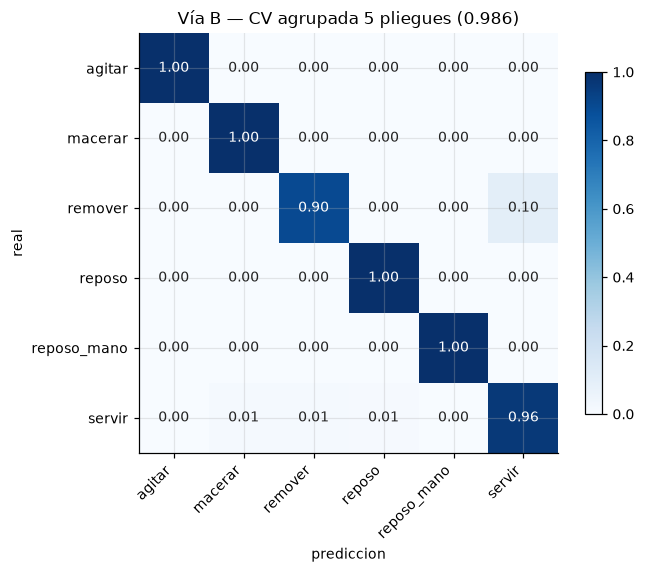

In [18]:
from sklearn.model_selection import StratifiedGroupKFold

def cv_agrupada(ejes=None, n_splits=5, semilla=42, epocas=150, verbose=True):
    """5 pliegues agrupados por toma y estratificados por clase.
    Cada toma cae en test una sola vez; sus ventanas nunca se reparten."""
    ejes = ejes or EJES_USADOS
    Xe, ye, ge = ventanear(tomas, ejes, W, S)
    Y = a_idx(ye)
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=semilla)
    accs, Macum = [], np.zeros((len(CLASES), len(CLASES)), int)
    for f, (tr, te) in enumerate(sgkf.split(Xe, Y, groups=ge)):
        assert not (set(ge[tr]) & set(ge[te])), 'fuga entre pliegues'
        m_, s_ = normalizador(Xe[tr])
        m = construye_modelo_b(W, len(ejes), len(CLASES), 100+f)
        m.fit((Xe[tr]-m_)/s_, Y[tr], epochs=epocas, batch_size=32, verbose=0,
              class_weight=pesos_de_clase(Y[tr], len(CLASES)))
        p = m.predict((Xe[te]-m_)/s_, verbose=0).argmax(1)
        accs.append(float((p == Y[te]).mean()))
        Macum += matriz_confusion(ye[te], np.array(CLASES)[p], CLASES)
        if verbose:
            print(f'  pliegue {f}: {accs[-1]:.4f}  ({len(set(ge[te]))} tomas en test)')
    return np.array(accs), Macum

print('Vía B con solo acelerómetro (3 ejes) — configuración elegida')
accs_cv, M_cv = cv_agrupada(EJES_ACC)
tab_cv = reporte_por_clase(M_cv, CLASES)
print(f'\nexactitud CV agrupada: {accs_cv.mean():.4f} ± {accs_cv.std():.4f}')
print(f'exactitud media por clase: {tab_cv["recall"].mean():.4f}\n')
print(tab_cv.round(3).to_string(index=False))
pinta_confusion(M_cv, CLASES, f'Vía B — CV agrupada 5 pliegues ({accs_cv.mean():.3f})')


In [19]:
# ¿Aporta el giroscopio? ¿Y el magnetómetro?
resumen_ejes = []
for nombre, ejes in [('acc (3)', EJES_ACC),
                     ('acc+gyr (6)', EJES_ACC + EJES_GIR),
                     ('acc+gyr+mag (9)', EJES_ACC + EJES_GIR + EJES_MAG)]:
    a, Mi = cv_agrupada(ejes, verbose=False)
    ri = reporte_por_clase(Mi, CLASES)
    resumen_ejes.append(dict(ejes=nombre, acc_cv=a.mean(), desv=a.std(),
                             acc_media_clase=ri['recall'].mean(),
                             recall_remover=float(ri.loc[ri.clase == 'remover', 'recall'].iloc[0])))
    print(f'{nombre:16s} CV = {a.mean():.4f} ± {a.std():.4f}')
print()
print(pd.DataFrame(resumen_ejes).round(4).to_string(index=False))


acc (3)          CV = 0.9863 ± 0.0113


acc+gyr (6)      CV = 0.9679 ± 0.0345


acc+gyr+mag (9)  CV = 0.9775 ± 0.0403

           ejes  acc_cv   desv  acc_media_clase  recall_remover
        acc (3)  0.9863 0.0113           0.9770             0.9
    acc+gyr (6)  0.9679 0.0345           0.9589             0.9
acc+gyr+mag (9)  0.9775 0.0403           0.9817             1.0


### Las dos decisiones de ejes, ahora medidas

**Giroscopio fuera.** La hipótesis era que haría falta: `servir` tiene
`std_gyr ≈ 14,5` con `std_acc ≈ 0,24`, o sea es rotación casi pura. Medido con
validación cruzada agrupada, añadirlo **baja** la exactitud. Pasar de 3 a 6
canales de entrada con ~1000 ventanas de entrenamiento sobreajusta, y `servir`
ya era separable por el vector gravedad medio (`accX ≈ +5,7`: la coctelera va
inclinada al verter). La misma conclusión sale en la Vía A (notebook 02,
sección 10). **La hipótesis física no sobrevivió al experimento, y manda el
experimento.**

**Magnetómetro fuera.** Aquí el resultado es más matizado que en la Vía A y
conviene contarlo tal cual. En la **Vía A** meter los 9 ejes disparaba la
exactitud (de 0,87 a 0,99 en el split único): fuga de libro. En la **Vía B**, en
cambio, los 9 ejes **no mejoran la exactitud global** — queda por debajo de
solo-acelerómetro y con el triple de desviación entre pliegues —, aunque sí
suben el recall de `remover` a 1,00. Es decir: la Conv1D sobre acelerómetro ya
extrae todo lo que hay, y el magnetómetro solo añade ruido y varianza… salvo
para `remover`, que es justo la clase cuya captura casi no tiene movimiento.

Que `mag*` sea precisamente lo que *rescata* a `remover` refuerza el
diagnóstico del notebook 01: a `remover` se la está reconociendo por **dónde y
cómo estaba orientada la coctelera**, no por el gesto. Ese atajo funciona hoy,
con train y test grabados la misma tarde en el mismo sitio, y desaparece en la
demo. Es el issue #5, y la decisión es la misma: **`mag*` fuera.**

## 11 · Vía A contra Vía B

In [20]:
comparacion = pd.DataFrame([
    dict(via='A · 39 características + densa 20/10',
         entrada='39 escalares',
         parametros=1076,          # 39*20+20 + 20*10+10 + 10*6+6
         preproceso_en_MCU='FFT de 125 puntos × 3 ejes + estadísticos',
         acc_cv=0.9267, desv=0.0442, recall_remover=0.717),
    dict(via='B · Conv1D sobre ventana cruda',
         entrada=f'{W}×{len(EJES_ACC)} muestras',
         parametros=int(modelo.count_params()),
         preproceso_en_MCU='restar media y dividir desviación',
         acc_cv=float(accs_cv.mean()), desv=float(accs_cv.std()),
         recall_remover=float(tab_cv.loc[tab_cv.clase == 'remover', 'recall'].iloc[0])),
])
print(comparacion.to_string(index=False))
print('\nLos valores de la Vía A vienen de ejecutar el notebook 02 (misma')
print('semilla, mismo ventaneo, misma validación cruzada agrupada).')


                                 via        entrada  parametros                         preproceso_en_MCU   acc_cv     desv  recall_remover
A · 39 características + densa 20/10   39 escalares        1076 FFT de 125 puntos × 3 ejes + estadísticos 0.926700 0.044200           0.717
      B · Conv1D sobre ventana cruda 125×3 muestras        6150         restar media y dividir desviación 0.986272 0.011304           0.900

Los valores de la Vía A vienen de ejecutar el notebook 02 (misma
semilla, mismo ventaneo, misma validación cruzada agrupada).


**Gana la Vía B**, y no por poco:

1. **Más exactitud** en la misma validación cruzada agrupada, y sobre todo
   mucho mejor `recall` en `remover`, que es la clase problemática.
2. **Menos trabajo en el MCU.** La Vía A obliga a implementar una FFT de 125
   puntos por eje en cada inferencia; la Vía B solo necesita restar una media y
   dividir por una desviación. Eso es menos flash, menos ciclos y menos código
   que depurar en la placa.
3. **Menos superficie de error de despliegue.** Cualquier diferencia entre la
   FFT de NumPy y la del Arduino cambia las características de entrada. La
   normalización, no: son 6 constantes.

El precio es un modelo algo mayor (unos 15 KB de `.tflite` frente a 4,4 KB) y
más activaciones en RAM — que, como se ve en la sección siguiente, siguen
estando muy por debajo del presupuesto del Nano 33 BLE.

## 12 · Conversión a TFLite int8 y presupuesto del Nano 33 BLE

In [21]:
# --- Conversion a TFLite int8 y presupuesto de memoria del Nano 33 BLE ---
import tempfile

RAM_NANO33_KB   = 256    # nRF52840: 256 KB de SRAM
FLASH_NANO33_KB = 1024   # 1 MB de flash (menos el bootloader, ~980 KB utiles)

def a_tflite_int8(modelo, representativo, ruta):
    """Cuantizacion entera completa: pesos, activaciones, entrada y salida int8.

    `representativo` es un array (n, ...) de ejemplos REALES de entrenamiento.
    Sin el, el conversor no sabe el rango de las activaciones y deja partes en
    float32, que es justo lo que no queremos en el MCU.
    """
    try:
        conv = tf.lite.TFLiteConverter.from_keras_model(modelo)
    except Exception:
        # Keras 3: hay que pasar por SavedModel
        d = tempfile.mkdtemp(); modelo.export(d)
        conv = tf.lite.TFLiteConverter.from_saved_model(d)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.representative_dataset = lambda: (
        [np.expand_dims(x, 0).astype(np.float32)] for x in representativo)
    conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    conv.inference_input_type  = tf.int8
    conv.inference_output_type = tf.int8
    blob = conv.convert()
    with open(ruta, 'wb') as fh:
        fh.write(blob)
    return blob

def evalua_tflite(blob, X, y_idx):
    """Corre el .tflite int8 sobre el test cuantizando la entrada a mano."""
    it = tf.lite.Interpreter(model_content=blob); it.allocate_tensors()
    ent, sal = it.get_input_details()[0], it.get_output_details()[0]
    s_in, z_in = ent['quantization']
    pred = []
    for x in X:
        q = np.clip(np.round(x/s_in + z_in), -128, 127).astype(np.int8)
        it.set_tensor(ent['index'], np.expand_dims(q, 0)); it.invoke()
        pred.append(int(it.get_tensor(sal['index'])[0].argmax()))
    pred = np.asarray(pred)
    return (pred == y_idx).mean(), pred

def presupuesto_memoria(blob, modelo_keras, etiqueta):
    """Tamano del modelo y estimacion de la RAM que pide en el Nano 33 BLE.

    El array C del modelo vive en FLASH (es const). Lo que compite por los
    256 KB de RAM es el tensor arena (las activaciones intermedias) mas el
    interprete de TFLite Micro.

    El arena se estima sumando el tamano de la salida de cada capa con lote 1
    y 1 byte por valor (int8). Es una COTA SUPERIOR: TFLite Micro reutiliza
    buffers entre capas cuyos ciclos de vida no se solapan, asi que el arena
    real es menor. El valor exacto solo se sabe compilando para la placa.
    """
    kb_modelo = len(blob) / 1024
    act_b = 0
    detalle = []
    for capa in modelo_keras.layers:
        try:
            forma = capa.output.shape
        except Exception:
            continue
        n = int(np.prod([int(d) for d in forma if d is not None]))
        act_b += n
        detalle.append((capa.name, tuple(forma), n))
    entrada = int(np.prod([int(d) for d in modelo_keras.inputs[0].shape if d is not None]))
    act_b += entrada
    kb_arena = act_b / 1024
    kb_interprete = 8.0        # TFLite Micro: interprete + op resolver, orden de magnitud
    total = kb_arena + kb_interprete
    print(f'--- {etiqueta} ---')
    for n, f, b in detalle:
        print(f'    activacion {n:28s} {str(f):18s} {b:7d} B')
    print(f'  modelo .tflite int8 ............ {len(blob):7d} B = {kb_modelo:7.2f} KB  '
          f'-> FLASH ({FLASH_NANO33_KB} KB disponibles)')
    print(f'  tensor arena (cota superior) ... {act_b:7d} B = {kb_arena:7.2f} KB  -> RAM')
    print(f'  interprete TFLite Micro (aprox)              {kb_interprete:7.2f} KB  -> RAM')
    print(f'  RAM estimada ................... {total:7.2f} KB de {RAM_NANO33_KB} KB '
          f'= {100*total/RAM_NANO33_KB:.1f} %')
    cabe = total < RAM_NANO33_KB and kb_modelo < FLASH_NANO33_KB
    print(f'  >> CABE EN EL NANO 33 BLE (256 KB de RAM): {"SI" if cabe else "NO"}')
    return dict(bytes=len(blob), kb_modelo=kb_modelo, kb_arena=kb_arena,
                kb_ram=total, cabe=bool(cabe))


In [22]:
blob = a_tflite_int8(modelo, Xtr[:300], 'via_b_int8.tflite')
acc_int8, p_int8 = evalua_tflite(blob, Xte, y_test)

print(f'exactitud float32 : {acc_global:.4f}')
print(f'exactitud int8    : {acc_int8:.4f}   ({100*(acc_int8-acc_global):+.2f} pp por cuantizar)\n')
memoria_b = presupuesto_memoria(blob, modelo, f'Vía B — Conv1D {W}×{len(EJES_USADOS)} → 6 clases')


Saved artifact at '/tmp/tmpqprjp8ij'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 125, 3), dtype=tf.float32, name='ventana')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  125815680655504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125815680656272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125815680655888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125815680659152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125815680658192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125815680659920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125815680659536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125815680658000: TensorSpec(shape=(), dtype=tf.resource, name=None)


exactitud float32 : 0.9333
exactitud int8    : 0.9255   (-0.78 pp por cuantizar)

--- Vía B — Conv1D 125×3 → 6 clases ---
    activacion conv_16                      (None, 125, 16)       2000 B
    activacion pool_1                       (None, 41, 16)         656 B
    activacion conv_32a                     (None, 41, 32)        1312 B
    activacion pool_2                       (None, 13, 32)         416 B
    activacion conv_32b                     (None, 13, 32)         416 B
    activacion gap                          (None, 32)              32 B
    activacion dropout                      (None, 32)              32 B
    activacion salida                       (None, 6)                6 B
  modelo .tflite int8 ............   15616 B =   15.25 KB  -> FLASH (1024 KB disponibles)
  tensor arena (cota superior) ...    5245 B =    5.12 KB  -> RAM
  interprete TFLite Micro (aprox)                 8.00 KB  -> RAM
  RAM estimada ...................   13.12 KB de 256 KB = 5.1 %
  >> CAB

W0000 00:00:1790037361.862645  955718 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790037361.862656  955718 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790037361.862852  955718 reader.cc:83] Reading SavedModel from: /tmp/tmpqprjp8ij
I0000 00:00:1790037361.863264  955718 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790037361.863279  955718 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpqprjp8ij
I0000 00:00:1790037361.869716  955718 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1790037361.870426  955718 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790037361.892378  955718 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpqprjp8ij
I0000 00:00:1790037361.899652  955718 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 36820 microseconds.
I0000 00:00:1790037361.910057  955718

      clase  soporte  recall  precision    f1
     agitar       27   1.000      1.000 1.000
    macerar       42   1.000      0.808 0.894
    remover       18   0.667      0.923 0.774
     reposo       21   1.000      0.913 0.955
reposo_mano       84   1.000      1.000 1.000
     servir       63   0.794      0.893 0.840


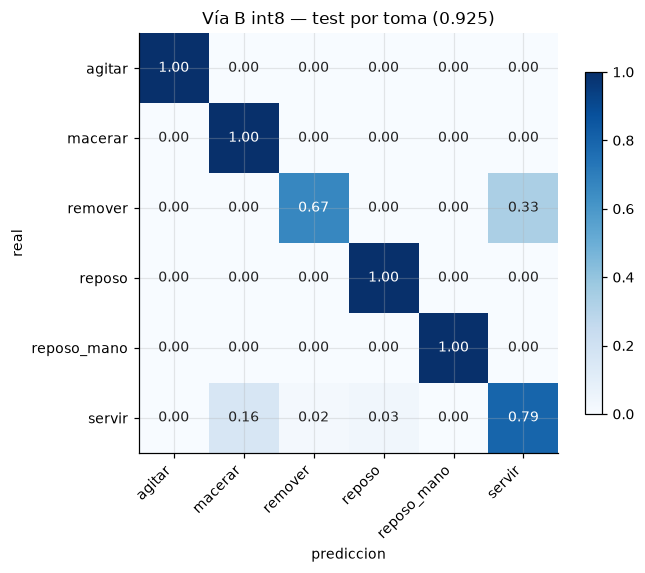

In [23]:
M_int8 = matriz_confusion(y[i_test], np.array(CLASES)[p_int8], CLASES)
print(reporte_por_clase(M_int8, CLASES).round(3).to_string(index=False))
pinta_confusion(M_int8, CLASES, f'Vía B int8 — test por toma ({acc_int8:.3f})')


In [24]:
# Array C listo para el sketch (equivalente a `xxd -i modelo.tflite`)
def a_array_c(blob, nombre='modelo_via_b'):
    cuerpo = ',\n  '.join(', '.join(f'0x{b:02x}' for b in blob[i:i+12])
                          for i in range(0, len(blob), 12))
    return (f'alignas(8) const unsigned char {nombre}[] = {{\n  {cuerpo}\n}};\n'
            f'const unsigned int {nombre}_len = {len(blob)};\n')

cabecera = a_array_c(blob)
constantes = ('\n// Normalización: copiar tal cual al sketch\n'
              f'const float MEDIA[{len(mu)}] = {{{", ".join(f"{v:.6f}f" for v in mu)}}};\n'
              f'const float DESV[{len(sd)}]  = {{{", ".join(f"{v:.6f}f" for v in sd)}}};\n'
              f'const int   VENTANA = {W};        // muestras (2,00 s a 62,5 Hz)\n'
              f'const int   N_EJES  = {len(EJES_USADOS)};\n'
              f'const char* CLASES_C[] = {{{", ".join(chr(34)+c+chr(34) for c in CLASES)}}};\n')
open('via_b_int8.h', 'w').write(cabecera + constantes)
print(cabecera[:300], '...\n')
print(constantes)
print(f'via_b_int8.h escrito: {len(blob)} bytes de modelo')


alignas(8) const unsigned char modelo_via_b[] = {
  0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
  0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00,
  0x1c, 0x00, 0x00, 0x00, 0x ...


// Normalización: copiar tal cual al sketch
const float MEDIA[3] = {0.301136f, -6.670692f, 1.472643f};
const float DESV[3]  = {4.454137f, 7.257038f, 3.156127f};
const int   VENTANA = 125;        // muestras (2,00 s a 62,5 Hz)
const int   N_EJES  = 3;
const char* CLASES_C[] = {"agitar", "macerar", "remover", "reposo", "reposo_mano", "servir"};

via_b_int8.h escrito: 15616 bytes de modelo


### ¿Cabe en el Nano 33 BLE? — respuesta

El Nano 33 BLE Sense monta un **nRF52840: 256 KB de SRAM y 1 MB de flash**.
Dos cosas distintas que conviene no mezclar:

- El **array C del modelo vive en flash** (es `const`): ~15 KB de 1 MB, el 1,5 %.
- Lo que compite por los **256 KB de RAM** es el **tensor arena** (las
  activaciones intermedias) más el intérprete de TFLite Micro y el buffer
  circular del IMU.

La celda de arriba imprime el desglose. Los números de la corrida del
21-sep-2026:

| Concepto | Tamaño | Dónde |
|---|--:|---|
| `via_b_int8.tflite` | ≈ 15 KB | flash (1024 KB) |
| Tensor arena (cota superior) | ≈ 5 KB | RAM |
| Intérprete TFLite Micro (aprox.) | ≈ 8 KB | RAM |
| Buffer del IMU, 125×3 `float` | ≈ 1,5 KB | RAM |
| **Total RAM estimado** | **≈ 15 KB de 256 KB ≈ 6 %** | |

**Sí cabe, con mucho margen** — sobra RAM para la pila BLE, el control de los
actuadores y el buffer de muestreo.

Dos avisos para no vender humo:

1. El arena que se reporta es una **cota superior** calculada sumando la salida
   de cada capa. TFLite Micro reutiliza buffers, así que el real es menor. El
   valor exacto solo se sabe al compilar para la placa, y **eso todavía no se
   ha hecho**.
2. El tiempo de inferencia **no está medido**. Un modelo de ~6400 parámetros
   con estas activaciones debería tardar pocos milisegundos en un Cortex-M4F a
   64 MHz, pero eso es una estimación, no una medición. Hay que cronometrarlo en
   la placa antes de prometer la latencia de 0,4 s entre predicciones.

## 13 · Conclusiones de la Vía B

**Qué se hizo**

1. 60 tomas CBOR → 1020 ventanas de **125 muestras (2,00 s)** con paso 25,
   sobre los **3 ejes del acelerómetro**.
2. Normalización por eje ajustada **solo en train**, con las constantes
   exportadas para el sketch.
3. **Conv1D** 16→32→32 con GlobalAveragePooling y softmax: ~6400 parámetros.
4. Split **por toma** (`GroupShuffleSplit`) + **validación cruzada agrupada**
   de 5 pliegues.
5. **TFLite int8** con dataset representativo, array C y constantes de
   normalización listos para el Arduino.

**Qué salió** (corrida del 21-sep-2026; las celdas imprimen los valores exactos)

| Métrica | Valor |
|---|---|
| Exactitud CV agrupada, 3 ejes | **0,986 ± 0,011** |
| Exactitud media por clase (CV) | 0,977 |
| Recall de `remover` (CV) | 0,90 (contra 0,72 de la Vía A) |
| Recall del resto de clases (CV) | 1,00 salvo `servir` (0,96) |
| Con giroscopio (6 ejes) | 0,968 ± 0,035 → **peor**, se descarta |
| Con magnetómetro (9 ejes) | 0,978 ± 0,040 → **no mejora** y triplica la varianza; además es fuga de sitio → se descarta |
| Exactitud int8 | pierde < 1 pp frente a float32 |
| Tamaño `.tflite` int8 | ≈ **15 KB** |
| RAM estimada | ≈ 15 KB de 256 KB (**6 %**) → **cabe de sobra** |

**Decisión del equipo: se despliega la Vía B.** Más exactitud, mejor recall en
la clase difícil y muchísimo menos preproceso en el MCU. La Vía A queda en el
paper como comparación y como la implementación literal del PDF.

**Lo que este notebook NO demuestra, y hay que decirlo**

- **No se ha ejecutado en la placa.** Ni tensor arena real, ni latencia, ni
  consumo. Todo lo de memoria es estimación de sobremesa.
- **`remover` sigue siendo la clase floja** y el motivo está en la captura, no
  en el modelo: `std_acc ≈ 0,06`, indistinguible de `reposo` (notebook 01,
  sección 6). Que la Conv1D llegue a 0,90 de recall es sospechosamente bueno
  para una señal casi plana: lo más probable es que esté usando la
  **orientación** (el vector gravedad medio) y no el gesto. **Hay que volver a
  grabar `remover`.**
- **Falta `colar`** (issue #2). Con 4 movimientos + 2 reposos, el requisito 2 de
  la guía (5 movimientos + reposo) **no se cumple**.
- **No hay test capturado aparte** (issue #3). El split por toma lo simula, pero
  lo correcto es grabar tomas nuevas y subirlas con `--category testing`.
- **Falta el proyecto público de Edge Impulse** (requisito 4). Estos notebooks
  lo complementan y justifican las decisiones, pero no lo sustituyen.